# Home Advantage in Ekstraklasa 1989-2023

## Introduction
This project analyzes the role of home advantage in Polish football's top division — Ekstraklasa.
The main questions are:
- Does home advantage differentiate champions from the rest of the table?
- Has home advantage changed over the last 30 years?

Data source: Kaggle — Ekstraklasa 1989-2023

## Data Preparation
Loading the dataset and cleaning the data — splitting the result column into home and away goals,
converting dates, assigning seasons and calculating points for each match.

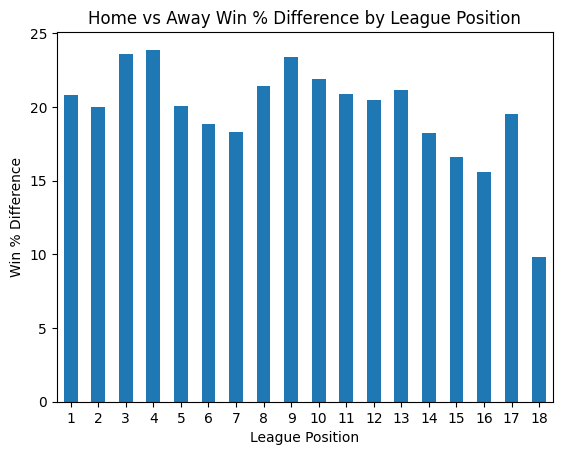

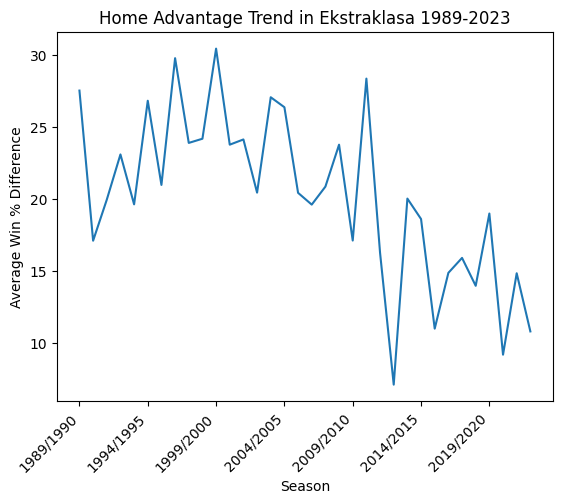

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

liga = pd.read_csv("ekstraklasa_1989_2023.csv")




In [8]:
# Converts date to season format (e.g. 2021/2022)
# Seasons start in July, except 2019/2020 which started in August due to COVID-19.
def data2sezon (dane):
  if dane["data"].year == 2020 and dane["data"].month < 8:
    return "2019/2020"
  elif dane["data"].month < 7:
      sezon = str(dane["data"].year - 1) + "/" + str(dane["data"].year)
  else:
    sezon = str(dane["data"].year) + "/" + str(dane["data"].year + 1)
  return sezon

# Calculates points for home and away team based on match result.
# Before 1996/1997 season, a win was worth 2 points instead of 3.
# Returns a tuple (home_pts, away_pts).
def pts(dane):
    win_pts = 2 if dane["sezon"] < "1996/1997" else 3
    diff = dane["home_goals"] - dane["away_goals"]
    if diff > 0:
        return win_pts, 0
    elif diff == 0:
        return 1, 1
    else:
        return 0, win_pts


# Builds a full league table for a given season.
# Aggregates home and away stats separately, then merges them.
# Returns a DataFrame sorted by points and goal difference.
def season_table (season):
  league_year = liga[liga["sezon"] == season]
  league_year_home = league_year.groupby("dom").agg(home_pts=("home_pts","sum"),
                                              home_goals_scored =("home_goals", "sum"),
                                              home_goals_conceded =("away_goals", 'sum'),
                                              home_wins=("home_pts", lambda x: ((x == 3) | (x == 2)).sum()),
                                              home_draws=("home_pts", lambda x: (x == 1).sum()),
                                              home_loses=("home_pts", lambda x: (x == 0).sum())).reset_index()

  league_year_away = league_year.groupby("wyjazd").agg(away_pts=("away_pts", "sum"),
                                                away_goals_scored=("away_goals", "sum"),
                                                away_goals_conceded=("home_goals", "sum"),
                                                away_wins=("away_pts", lambda x: ((x == 3) | (x == 2)).sum()),
                                                away_draws=("away_pts", lambda x: (x == 1).sum()),
                                                away_loses=("away_pts", lambda x: (x == 0).sum())).reset_index()

  table = league_year_home.merge(league_year_away, right_on="wyjazd", left_on="dom", how="inner")
  table = table.drop(columns =["wyjazd"]).rename(columns= {"dom": "team"})
  table["pts"] = table["home_pts"] + table["away_pts"]

  table["goal_diff"] = table["home_goals_scored"] - table["home_goals_conceded"] + table["away_goals_scored"] - table["away_goals_conceded"]
  table = table.sort_values(by = ["pts", "goal_diff"], ascending = False).reset_index(drop=True)

  table["home_win_pct"] = round(table["home_wins"] / (table["home_wins"] + table["home_draws"] + table["home_loses"]) * 100, 1)
  table["away_win_pct"] = round(table["away_wins"] / (table["away_wins"] + table["away_draws"] + table["away_loses"]) * 100, 1)

  table = table[[ "team", "pts", "goal_diff", "home_win_pct",
                  "home_pts", "home_wins", "home_draws", "home_loses",
                  "away_win_pct", "away_pts", "away_wins",
                  "away_draws", "away_loses", "home_goals_scored",
                  "home_goals_conceded", "away_goals_scored", "away_goals_conceded"]]
  return table






liga [["home_goals", "away_goals"]] = liga["wynik"].str.split(":", expand = True).astype(int)

liga["data"] = pd.to_datetime(liga["data"])


liga["sezon"] = liga.apply(data2sezon, axis= 1)
liga = liga[liga["sezon"] != "2023/2024"]
liga = liga[["sezon", "dom", "wyjazd",
             "wynik", "home_goals", "away_goals"]]

liga[["dom", "wyjazd"]] = liga[["dom", "wyjazd"]].replace({"TS Tygodnik Miliarder Pniewy": "Miliarder Pniewy", "Sokol Tychy": "GKS Tychy"})

liga[["home_pts", "away_pts"]] = liga.apply(pts, axis = 1, result_type="expand")


all_seasons  = []
for sezon in liga["sezon"].unique():
  t = season_table(sezon)
  t["place"] = t.index + 1
  t["season"] = sezon
  all_seasons.append(t)

# Build league tables for all seasons and combine into one DataFrame
all_seasons = pd.concat(all_seasons)

all_seasons["home_away_diff"] = all_seasons["home_win_pct"] - all_seasons["away_win_pct"]




## Analysis
Comparing home and away win percentages across league positions and seasons.

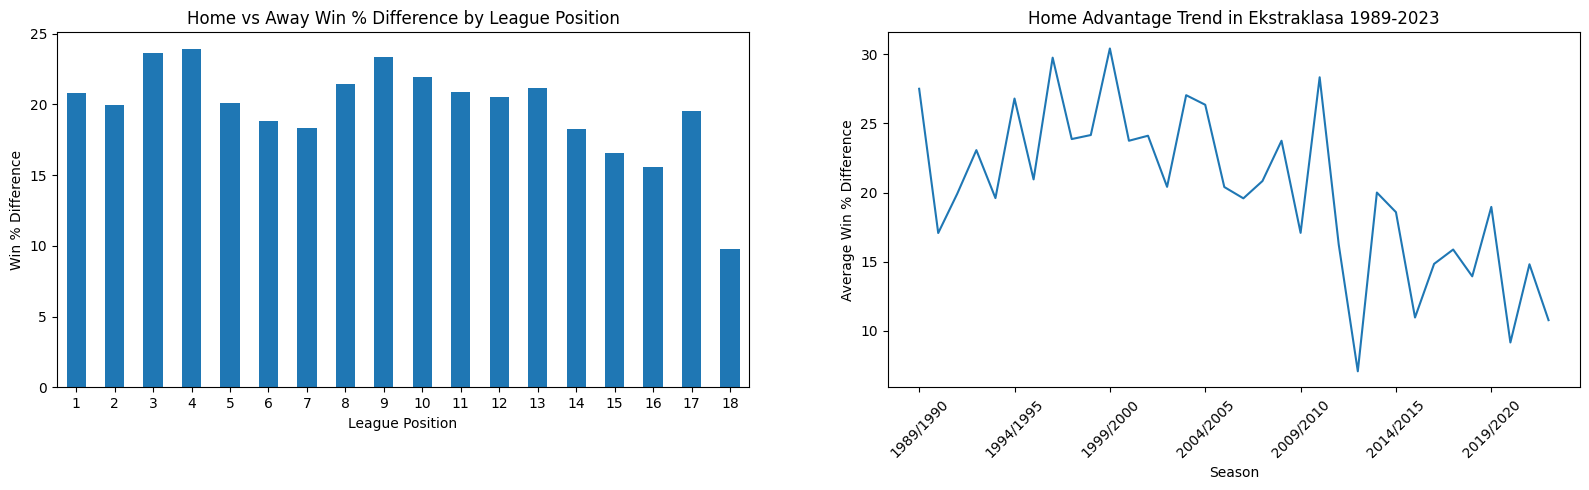

In [14]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

all_seasons.groupby("place")["home_away_diff"].mean().plot(kind="bar", ax=ax1)
ax1.set_title("Home vs Away Win % Difference by League Position")
ax1.set_xlabel("League Position")
ax1.set_ylabel("Win % Difference")
ax1.tick_params(axis='x', rotation=0)

all_seasons.groupby("season")["home_away_diff"].mean().plot(kind="line", ax=ax2)
ax2.set_title("Home Advantage Trend in Ekstraklasa 1989-2023")
ax2.set_xlabel("Season")
ax2.set_ylabel("Average Win % Difference")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

## Conclusions
- Home advantage does not significantly differentiate champions from the rest of the table.
  All teams tend to perform better at home regardless of their final position.
- However, home advantage in Ekstraklasa has been clearly declining over the last 30 years.
  In the 1990s the difference between home and away win % was around 20-30 points,
  while in recent seasons it dropped to around 10-20 points.